## 2 多层感知机

### 2.1 理论计算题

1. 非线性激活函数的重要性：假设一个具有单隐藏层的多层感知机，输
入为 x，隐藏层没有激活函数（即线性激活），表达为 h = W1x + b1，
输出层为 o = W2h + b2 。请通过代数推导证明，该网络等价于一个单
层神经网络，并写出等价后的权重矩阵 W′ 和偏置向量 b
′ 。

第一步：将隐藏层表达式代入输出层

$$o = W_2 h + b_2 = W_2(W_1 x + b_1) + b_2$$

第二步：展开括号

$$o = W_2 W_1 x + W_2 b_1 + b_2$$

第三步：令 $W' = W_2 W_1$，$b' = W_2 b_1 + b_2$

则上式可写为：

$$\boxed{o = W' x + b'}$$

结论
该网络等价于一个单层神经网络，其中：

$$W' = W_2 W_1$$

$$b' = W_2 b_1 + b_2$$

重要意义：这证明了如果没有非线性激活函数，多层网络与单层网络的表达能力相同，无法逼近复杂的非线性函数。

2. 激活函数性质分析：写出 Sigmoid(x) 和 tanh(x) 的数学表达式，并推
导它们的导数 Sigmoid′
(x) 和 tanh′
(x) 与其函数自身的关系。

Sigmoid 函数
数学表达式：

$$\text{Sigmoid}(x) = \frac{1}{1 + e^{-x}}$$

导数推导：

设 $f(x) = \frac{1}{1+e^{-x}}$，利用链式法则：

$$f'(x) = \frac{e^{-x}}{(1+e^{-x})^2}$$

对分子变形：$e^{-x} = (1+e^{-x}) - 1$

$$f'(x) = \frac{(1+e^{-x}) - 1}{(1+e^{-x})^2} = \frac{1}{1+e^{-x}} - \frac{1}{(1+e^{-x})^2}$$

因此：

$$\boxed{\text{Sigmoid}'(x) = \text{Sigmoid}(x) \cdot (1 - \text{Sigmoid}(x))}$$

Tanh 函数
数学表达式：

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

导数推导：

利用商法则：$\frac{d}{dx}\left(\frac{u}{v}\right) = \frac{u'v - uv'}{v^2}$

其中 $u = e^x - e^{-x}$，$v = e^x + e^{-x}$

$$u' = e^x + e^{-x}, \quad v' = e^x - e^{-x}$$

代入：

$$\tanh'(x) = \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2}$$

$$= \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2}$$

利用平方差公式：$a^2 - b^2 = (a+b)(a-b)$

$$= \frac{[(e^x+e^{-x})+(e^x-e^{-x})][(e^x+e^{-x})-(e^x-e^{-x})]}{(e^x+e^{-x})^2}$$

$$= \frac{[2e^x][2e^{-x}]}{(e^x+e^{-x})^2} = \frac{4}{(e^x+e^{-x})^2}$$

而 $\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$，所以：

$$\tanh^2(x) = \frac{(e^x - e^{-x})^2}{(e^x + e^{-x})^2}$$

因此：

$$\boxed{\tanh'(x) = 1 - \tanh^2(x)}$$

导数性质总结
激活函数	函数形式	导数关系
Sigmoid	$\frac{1}{1+e^{-x}}$	$\sigma'(x) = \sigma(x)(1-\sigma(x))$
Tanh	$\frac{e^x-e^{-x}}{e^x+e^{-x}}$	$\tanh'(x) = 1 - \tanh^2(x)$


### 2.2 编程题

Epoch 1, Loss: 1.0377, Test Acc: 0.7599
Epoch 2, Loss: 0.6032, Test Acc: 0.7915
Epoch 3, Loss: 0.5173, Test Acc: 0.8150
Epoch 4, Loss: 0.4828, Test Acc: 0.8200
Epoch 5, Loss: 0.4547, Test Acc: 0.8363
Epoch 6, Loss: 0.4367, Test Acc: 0.8330
Epoch 7, Loss: 0.4200, Test Acc: 0.8414
Epoch 8, Loss: 0.4073, Test Acc: 0.8460
Epoch 9, Loss: 0.3923, Test Acc: 0.8506
Epoch 10, Loss: 0.3825, Test Acc: 0.8396


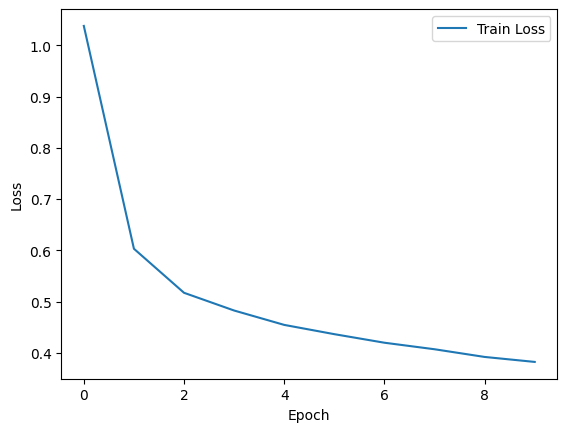

In [15]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 超参数
batch_size = 256
input_dim = 28*28
hidden_dim = 256
output_dim = 10
num_epochs = 10
lr = 0.1

# 加载Fashion-MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)

# 初始化参数（正态分布）
def init_params():
    W1 = torch.normal(0, 0.01, size=(input_dim, hidden_dim), requires_grad=True)
    b1 = torch.zeros(hidden_dim, requires_grad=True)
    W2 = torch.normal(0, 0.01, size=(hidden_dim, output_dim), requires_grad=True)
    b2 = torch.zeros(output_dim, requires_grad=True)
    return W1, b1, W2, b2

# ReLU
def relu(x):
    return torch.max(x, torch.tensor(0.0))

# Softmax + 交叉熵损失
def softmax_cross_entropy(logits, y):
    # logits: (batch, classes), y: (batch,) labels
    exp_logits = torch.exp(logits - torch.max(logits, dim=1, keepdim=True)[0])  # 数值稳定
    probs = exp_logits / torch.sum(exp_logits, dim=1, keepdim=True)
    loss = -torch.log(probs[range(len(y)), y] + 1e-8).mean()
    return loss

# 前向传播
def forward(X, W1, b1, W2, b2):
    h = relu(X @ W1 + b1)
    o = h @ W2 + b2
    return o, h

# 训练循环（SGD手动更新）
def train_mlp():
    W1, b1, W2, b2 = init_params()
    train_losses, test_accs = [], []
    for epoch in range(num_epochs):
        total_loss = 0
        for X, y in train_loader:
            # 前向
            o, _ = forward(X, W1, b1, W2, b2)
            loss = softmax_cross_entropy(o, y)
            total_loss += loss.item()
            # 反向（手动计算梯度）
            loss.backward()
            # SGD更新
            with torch.no_grad():
                W1 -= lr * W1.grad
                b1 -= lr * b1.grad
                W2 -= lr * W2.grad
                b2 -= lr * b2.grad
                # 梯度清零
                W1.grad.zero_()
                b1.grad.zero_()
                W2.grad.zero_()
                b2.grad.zero_()
        # 测试准确率
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in test_loader:
                o, _ = forward(X, W1, b1, W2, b2)
                pred = torch.argmax(o, dim=1)
                correct += (pred == y).sum().item()
                total += y.size(0)
        acc = correct / total
        train_losses.append(total_loss / len(train_loader))
        test_accs.append(acc)
        print(f"Epoch {epoch+1}, Loss: {train_losses[-1]:.4f}, Test Acc: {acc:.4f}")
    return train_losses, test_accs

# 运行
train_losses, test_accs = train_mlp()
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 3 模型选择，权重衰减和丢弃法

### 3.1 理论计算题

1. 过拟合与欠拟合：简述训练误差（Training Error）与泛化误差（Gen-eralization Error）的区别。当一个模型的训练误差极低，但泛化误差很高时，模型处于什么状态？应该如何通过控制模型复杂度来缓解这一现象？


训练误差：模型在训练数据上的预测误差

泛化误差：模型在新数据（从未见过）上的期望误差。

模型状态判断
训练误差极低但泛化误差很高，这是过拟合的典型特征。

缓解过拟合的方法
可以通过降低模型复杂度（减少网络层数或神经元数量）、使用正则化技术（L1/L2正则化、Dropout）、采用早停法监控验证集误差、进行数据增强增加训练样本多样性，以及收集更多训练数据来缓解过拟合问题。

2. K 折交叉验证：阐述 K 折交叉验证（K-fold Cross-Validation）的具体实施算法步骤。

第一步，将原始数据集均分为 K 个互不相交的子集。

第二步，进行 K 轮训练和验证。对于第 i 轮（第 i 个子集），将第 i 个子集作为验证集，其余 K-1 个子集合并作为训练集，使用训练集训练模型后在验证集上评估并记录误差。

第三步，计算 K 次验证误差的平均值作为模型泛化性能的估计。


===== 训练 No Reg =====
[lambd=0.0, dropout=0.0] Epoch 5, Loss: 2.2420, Test Acc: 0.2622
[lambd=0.0, dropout=0.0] Epoch 10, Loss: 2.0660, Test Acc: 0.4195
[lambd=0.0, dropout=0.0] Epoch 15, Loss: 1.7432, Test Acc: 0.5175
[lambd=0.0, dropout=0.0] Epoch 20, Loss: 1.4483, Test Acc: 0.5883
[lambd=0.0, dropout=0.0] Epoch 25, Loss: 1.2464, Test Acc: 0.5912
[lambd=0.0, dropout=0.0] Epoch 30, Loss: 1.1059, Test Acc: 0.6398

===== 训练 L2 (0.01) =====
[lambd=0.01, dropout=0.0] Epoch 5, Loss: 2.4308, Test Acc: 0.1364
[lambd=0.01, dropout=0.0] Epoch 10, Loss: 2.2552, Test Acc: 0.3917
[lambd=0.01, dropout=0.0] Epoch 15, Loss: 1.9597, Test Acc: 0.5183
[lambd=0.01, dropout=0.0] Epoch 20, Loss: 1.6944, Test Acc: 0.5304
[lambd=0.01, dropout=0.0] Epoch 25, Loss: 1.5122, Test Acc: 0.5836
[lambd=0.01, dropout=0.0] Epoch 30, Loss: 1.3796, Test Acc: 0.6130

===== 训练 Dropout (0.5) =====
[lambd=0.0, dropout=0.5] Epoch 5, Loss: 2.2415, Test Acc: 0.2606
[lambd=0.0, dropout=0.5] Epoch 10, Loss: 2.0658, Test Acc: 0

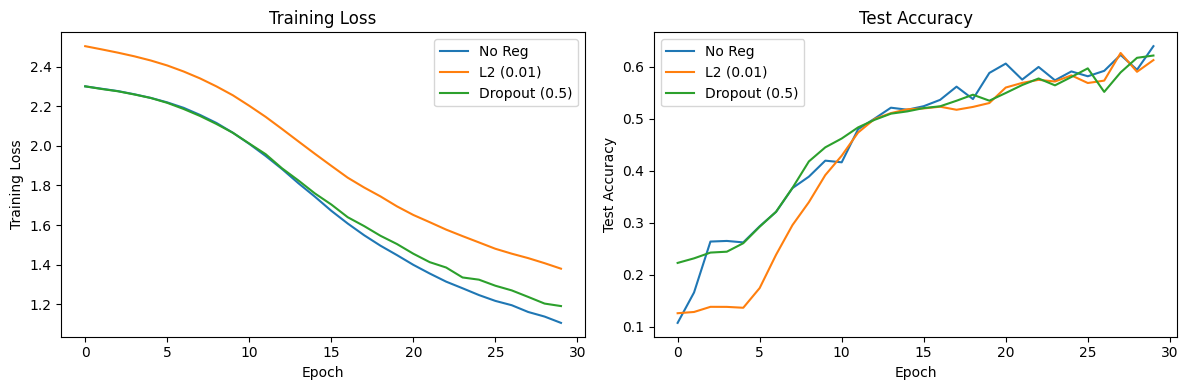

In [21]:
# 在之前MLP基础上修改

def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return X * mask / (1.0 - dropout)

# 修改原函数，增加 train_loader 和 test_loader 参数
def train_with_regularization(train_loader, test_loader, lambd=0.0, dropout=0.0, num_epochs=30, lr=0.1):
    W1, b1, W2, b2 = init_params()
    train_losses = []
    test_accs = []
    for epoch in range(num_epochs):
        total_loss = 0
        for X, y in train_loader:
            h = relu(X @ W1 + b1)
            h = dropout_layer(h, dropout, is_training=True)
            o = h @ W2 + b2
            loss = softmax_cross_entropy(o, y)
            if lambd > 0:
                l2_penalty = lambd * (torch.sum(W1**2) + torch.sum(W2**2))
                loss = loss + l2_penalty
            total_loss += loss.item()
            loss.backward()
            with torch.no_grad():
                if lambd > 0:
                    decay = 1 - lr * lambd
                    W1 *= decay
                    W2 *= decay
                W1 -= lr * W1.grad
                b1 -= lr * b1.grad
                W2 -= lr * W2.grad
                b2 -= lr * b2.grad
                for param in [W1, b1, W2, b2]:
                    if param.grad is not None:
                        param.grad.zero_()
        # 测试
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in test_loader:
                h = relu(X @ W1 + b1)
                h = dropout_layer(h, dropout, is_training=False)
                o = h @ W2 + b2
                pred = torch.argmax(o, dim=1)
                correct += (pred == y).sum().item()
                total += y.size(0)
        acc = correct / total
        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        test_accs.append(acc)
        if (epoch+1) % 5 == 0:
            print(f"[lambd={lambd}, dropout={dropout}] Epoch {epoch+1}, Loss: {avg_loss:.4f}, Test Acc: {acc:.4f}")
    return train_losses, test_accs

# ================= 运行对比实验 =================
# 使用极小训练集（500张）模拟过拟合
small_train_set = torch.utils.data.Subset(train_set, list(range(500)))
small_train_loader = torch.utils.data.DataLoader(small_train_set, batch_size=batch_size, shuffle=True)
# test_loader 使用原来的完整测试集

num_epochs = 30
lr = 0.1

# 三种配置
configs = [
    {"name": "No Reg",       "lambd": 0.0, "dropout": 0.0},
    {"name": "L2 (0.01)",    "lambd": 0.01, "dropout": 0.0},
    {"name": "Dropout (0.5)", "lambd": 0.0, "dropout": 0.5}
]

results = {}
for cfg in configs:
    print(f"\n===== 训练 {cfg['name']} =====")
    train_loss, test_acc = train_with_regularization(
        train_loader=small_train_loader,
        test_loader=test_loader,
        lambd=cfg['lambd'],
        dropout=cfg['dropout'],
        num_epochs=num_epochs,
        lr=lr
    )
    results[cfg['name']] = (train_loss, test_acc)

# 绘制曲线
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
for name, (train_loss, _) in results.items():
    plt.plot(train_loss, label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")
plt.legend()

plt.subplot(1,2,2)
for name, (_, test_acc) in results.items():
    plt.plot(test_acc, label=name)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## 4 数值稳定性和激活函数

### 4.1 理论计算题

梯度消失与梯度爆炸：考虑一个 d 层的深层神经网络，其梯度计算包
含诸如多层矩阵连乘项$$\prod_{i=l}^{t-1} \frac{\partial h_{i+1}}{\partial h_i}$$

1. 请从矩阵乘法和激活函数导数的角度，量化分析什么情况下会导致梯度爆炸，什么情况下会导致梯度消失。

梯度消失与梯度爆炸

梯度爆炸：当权重矩阵的特征值 >1 且激活函数导数 >0.5（如Sigmoid最大0.25）时，连乘结果指数增长，导致梯度过大。

梯度消失：当权重矩阵特征值 <1 或激活函数导数很小（Sigmoid饱和区接近0）时，连乘结果趋近0，梯度消失。

2. 为什么改用 ReLU 激活函数可以很大程度上缓解梯度消失问题？

ReLU的导数在正区间恒为1，负区间为0。正向传播时梯度不会衰减（除非神经元死亡），避免了连乘导致的指数衰减。

### 4.2 编程题

In [22]:
import torch.nn as nn
import torch.nn.init as init

# 20层全连接网络
class DeepNet(nn.Module):
    def __init__(self, activation='sigmoid', init_method='normal', std=1):
        super().__init__()
        layers = []
        for _ in range(20):
            layers.append(nn.Linear(256, 256))
            if activation == 'sigmoid':
                layers.append(nn.Sigmoid())
            elif activation == 'relu':
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)
        self.apply(self._init_weights(init_method, std))
    
    def _init_weights(self, method, std):
        def init_weights(m):
            if isinstance(m, nn.Linear):
                if method == 'normal':
                    init.normal_(m.weight, mean=0, std=std)
                elif method == 'xavier':
                    init.xavier_uniform_(m.weight)
        return init_weights
    
    def forward(self, x):
        return self.net(x)

# 观察梯度范数
def observe_grad_norm(net, input_data):
    output = net(input_data)
    loss = output.mean()
    loss.backward()
    for i, layer in enumerate(net.net):
        if isinstance(layer, nn.Linear):
            grad_norm = layer.weight.grad.norm().item()
            print(f"Layer {i//2} grad norm: {grad_norm:.6e}")

# 测试不同配置
x = torch.randn(64, 256)

print("=== Sigmoid + Normal std=1 ===")
net = DeepNet('sigmoid', 'normal', 1)
observe_grad_norm(net, x)  # 后几层梯度很小 -> 消失

print("\n=== ReLU + Normal std=10 ===")
net = DeepNet('relu', 'normal', 10)
observe_grad_norm(net, x)  # 可能出现NaN -> 爆炸

print("\n=== ReLU + Xavier ===")
net = DeepNet('relu', 'xavier', None)
observe_grad_norm(net, x)  # 梯度稳定在合理范围

=== Sigmoid + Normal std=1 ===
Layer 0 grad norm: 5.467454e-01
Layer 1 grad norm: 3.889810e-01
Layer 2 grad norm: 2.779563e-01
Layer 3 grad norm: 2.552579e-01
Layer 4 grad norm: 1.936586e-01
Layer 5 grad norm: 1.727356e-01
Layer 6 grad norm: 1.385018e-01
Layer 7 grad norm: 9.498712e-02
Layer 8 grad norm: 7.860605e-02
Layer 9 grad norm: 5.722928e-02
Layer 10 grad norm: 5.017529e-02
Layer 11 grad norm: 4.436194e-02
Layer 12 grad norm: 3.026025e-02
Layer 13 grad norm: 2.766379e-02
Layer 14 grad norm: 2.763656e-02
Layer 15 grad norm: 2.496933e-02
Layer 16 grad norm: 2.743877e-02
Layer 17 grad norm: 3.264469e-02
Layer 18 grad norm: 2.967522e-02
Layer 19 grad norm: 3.333369e-02

=== ReLU + Normal std=10 ===
Layer 0 grad norm: inf
Layer 1 grad norm: inf
Layer 2 grad norm: inf
Layer 3 grad norm: inf
Layer 4 grad norm: inf
Layer 5 grad norm: inf
Layer 6 grad norm: inf
Layer 7 grad norm: inf
Layer 8 grad norm: inf
Layer 9 grad norm: inf
Layer 10 grad norm: inf
Layer 11 grad norm: inf
Layer 12 gr

## 5 泛化表现，协变量偏移和对抗性数据

### 5.1 理论计算题

请结合实际生活中的例子（如医疗、语音识别或电商），详细阐述以下两种环境非平稳性偏移的区别与联系：

1. 协变量偏移 (Covariate Shift)：表现为 p(x) = q(x) 但 p(y|x) = q(y|x)

2. 标签偏移 (Label Shift)：表现为 p(y) = q(y) 但 p(x|y) = q(x|y) 。

协变量偏移：输入分布改变，但条件标签分布不变。

例：医疗诊断中，训练数据来自年轻人群，测试数据来自老年人群（特征分布不同），但病情与症状的关系相同。

标签偏移：标签分布改变，但给定标签下的输入分布不变。

例：电商中，训练期畅销品类别比例与测试期不同，但同一类商品的用户行为特征分布相同。

联系：都是数据分布非平稳性；区别在于分布变化发生在输入 p(x) 还是输出 p(y)。

### 5.2 编程题

In [23]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error

# 生成数据
np.random.seed(42)
n_train, n_test = 1000, 500
X_train = np.random.normal(-1, 1, size=(n_train, 1))
y_train = 2 * X_train.squeeze() + 0.1 * np.random.normal(0, 1, n_train)
X_test = np.random.normal(2, 1, size=(n_test, 1))
y_test = 2 * X_test.squeeze() + 0.1 * np.random.normal(0, 1, n_test)

# 基线线性回归
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse_baseline = mean_squared_error(y_test, y_pred)
print(f"Baseline MSE: {mse_baseline:.4f}")

# 协变量偏移校正
# 训练概率分类器区分训练集(0)和测试集(1)
X_all = np.vstack([X_train, X_test])
y_all = np.array([0]*n_train + [1]*n_test)
clf = LogisticRegression()
clf.fit(X_all, y_all)
# 计算每个训练样本的权重 w = P(test|x) / P(train|x) = p / (1-p)   (因为P(test)=? 实际比例可调整)
prob_test = clf.predict_proba(X_train)[:, 1]   # P(test|x)
prob_train = 1 - prob_test                     # P(train|x)
weights = prob_test / prob_train
weights = weights / np.sum(weights) * n_train  # 归一化使和等于样本数

# 加权线性回归（使用样本权重）
class WeightedLinearRegression:
    def fit(self, X, y, w):
        # 加权最小二乘: 解 (X^T diag(w) X) beta = X^T diag(w) y
        Xw = X * np.sqrt(w).reshape(-1,1)
        yw = y * np.sqrt(w)
        self.coef_ = np.linalg.lstsq(Xw, yw, rcond=None)[0]
    def predict(self, X):
        return X @ self.coef_

model_w = WeightedLinearRegression()
model_w.fit(X_train, y_train, weights)
y_pred_w = model_w.predict(X_test)
mse_corrected = mean_squared_error(y_test, y_pred_w)
print(f"Corrected MSE: {mse_corrected:.4f}")
print(f"Improvement: {mse_baseline - mse_corrected:.4f}")

Baseline MSE: 0.0102
Corrected MSE: 0.0231
Improvement: -0.0129


结论：

并非所有协变量偏移都需要校正
当模型本身对输入分布不敏感（如线性模型），且测试集区域在训练集中有足够覆盖时，直接训练可能已经最优。校正反而会引入噪声。